In [1]:
from sklearn.model_selection import cross_val_score# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output.

/kaggle/input/usinlppracticum/imdb_test.csv
/kaggle/input/usinlppracticum/imdb_train.csv
/kaggle/input/usinlppracticum/sample_submission.csv


In [2]:
df = pd.read_csv("/kaggle/input/usinlppracticum/imdb_train.csv")

In [3]:
df["sentiment"] = df["sentiment"].map({'negative':0,'positive':1})

In [4]:
df.head()

,review,sentiment
0,We had STARZ free weekend and I switched on th...,0
1,I'll admit that this isn't a great film. It pr...,0
2,I finally found a version of Persuasion that I...,1
3,The BBC surpassed themselves with the boundari...,1
4,"Much praise has been lavished upon Farscape, b...",0


In [5]:
df.iloc[1]['review']

'I\'ll admit that this isn\'t a great film. It practically screams "low-budget" yet oddly I still found myself liking the film because although it lacked quality it abounded with energy. It was like the Little Engine That Could and a movie merged into one! <br /><br />The film takes place at a radio network and concerns some of their low-level employees--two page boys (one very pushy and brash and the other one a wuss) as well as a new receptionist. All three have visions of radio stardom but must for now content themselves with their lowly jobs.<br /><br />Into this story appears a murder that seems somewhat out of the blue. I didn\'t know that this was a murder mystery film and was taken a bit by surprise. However, like most B-mysteries, the cops are lamebrains and it\'s up to our pushy hero (Moran) to try to save the day. Throughout all this, I had a hard time deciding if Moran was obnoxious or endearing. I\'m still not sure!! <br /><br />There is a moment in the film that is high o

In [6]:
#Data Cleaning
import re
import string

def clean_text_round1(text):
    '''Make text lowercase, remove punctuation and remove words containing numbers.'''
    text = text.lower()
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\w*\d\w*', '', text)
    text = re.sub('[‘’“”…]', '', text)
    return text

round1 = lambda x: clean_text_round1(x)

In [7]:
# Let's take a look at the updated text
df.review = pd.DataFrame(df.review.apply(round1))
df

,review,sentiment
0,we had starz free weekend and i switched on th...,0
1,ill admit that this isnt a great film it pract...,0
2,i finally found a version of persuasion that i...,1
3,the bbc surpassed themselves with the boundari...,1
4,much praise has been lavished upon farscape bu...,0
...,...,...
39995,i realize several ben stiller movies are out o...,0
39996,buyer beware the alpha video release uses a pr...,0
39997,the falcon the snowman offers some of the bes...,1
39998,what can you say about a grainy poorly filmed ...,0


In [8]:
# data_clean.iloc[0]['review']

In [9]:
# data_clean.iloc[7]['review']

In [10]:
import pickle

In [21]:
df['total_words'] = df['review'].str.count(' ') + 1
print(df.loc[df.total_words.idxmax()])
print("\nThe longest comment is " + str(df['total_words'].max()) + " words.\n")

review         match  tag team table match bubba ray and spik...
sentiment                                                      1
total_words                                                 2470
Name: 13739, dtype: object

The longest comment is 2470 words.



In [22]:
df.head()

,review,sentiment,total_words
0,we had starz free weekend and i switched on th...,0,130
1,ill admit that this isnt a great film it pract...,0,367
2,i finally found a version of persuasion that i...,1,180
3,the bbc surpassed themselves with the boundari...,1,231
4,much praise has been lavished upon farscape bu...,0,455


In [23]:
import matplotlib.pyplot as plt

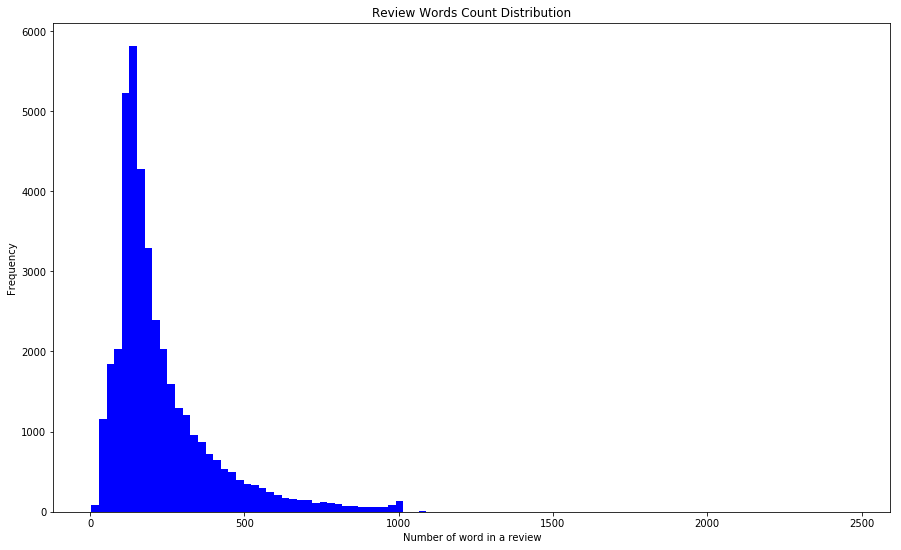

In [24]:
plt.figure(figsize=(15, 9))
plt.hist([(df['total_words'])],bins=100,color = "blue")
plt.xlabel('Number of word in a review')
plt.ylabel('Frequency')
plt.title('Review Words Count Distribution')
plt.show()

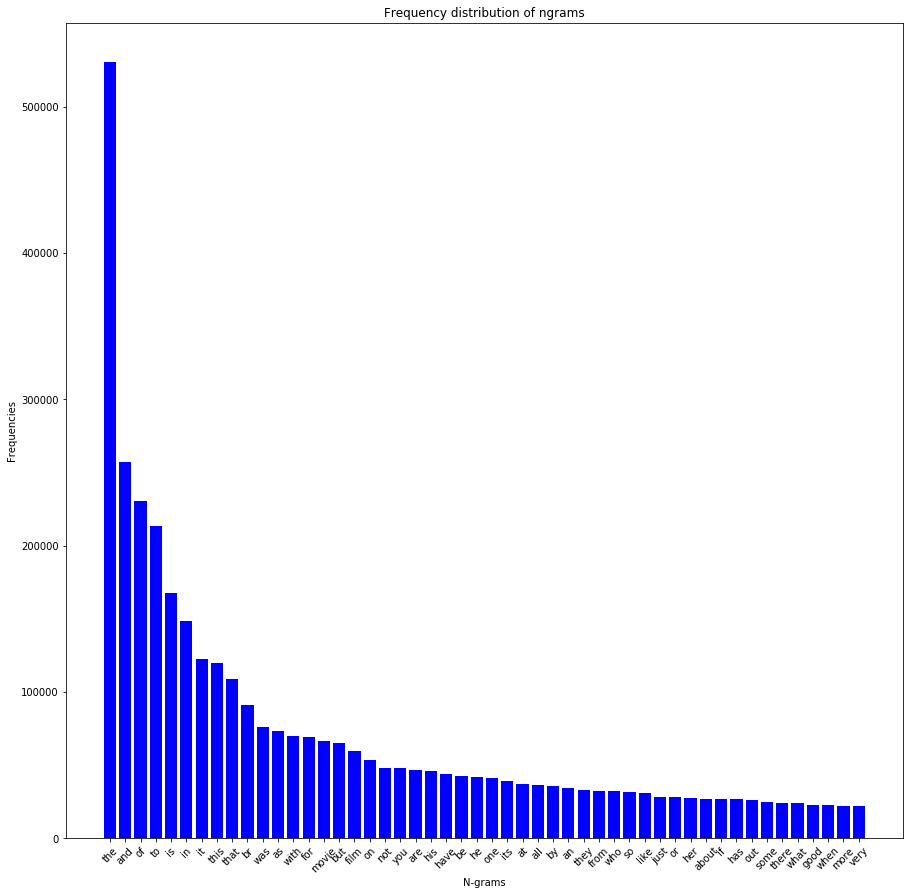

In [25]:
from sklearn.feature_extraction.text import CountVectorizer
CV = CountVectorizer()

# transform and vectorize the comments in a sparse matrix. The dimenion length is the number of instances, the width of the matrix is the
# number of words in total corpse. The words that are not in the each review is padded with 0, hence the sparse matrix.

vect_texts = CV.fit_transform(list(df['review']))
all_ngrams = CV.get_feature_names()

# display top min(50,len(all_ngrams) of the most frequent words
num_ngrams = min(50, len(all_ngrams))

# count the number of words in the total corpse
all_counts = vect_texts.sum(axis=0).tolist()[0]

# loop the words(features) with counts using zip function
all_ngrams, all_counts = zip(*[(n, c) for c, n in sorted(zip(all_counts, all_ngrams), reverse=True)])
ngrams = all_ngrams[:num_ngrams]
counts = all_counts[:num_ngrams]

idx = np.arange(num_ngrams)

# Plot a frequency distribution plot of the most seen words in the corpus.
plt.figure(figsize=(15, 15))
plt.bar(idx, counts, width=0.8, color = "blue")
plt.xlabel('N-grams')
plt.ylabel('Frequencies')
plt.title('Frequency distribution of ngrams')
plt.xticks(idx, ngrams, rotation=45)
plt.show()


In [26]:
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2,f_classif, mutual_info_classif

# import a list of stopwords, when applied the stopwords in the corpose will not be tokenized, they will be skipped
stopwords=stopwords.words('english')

# min_df=2, any words that occurs less than 2 times in the total corpse will not be tokenized
vectorizer = TfidfVectorizer(min_df=2, binary=True, analyzer='word',ngram_range= (1,2), stop_words=stopwords)
df_bigram = vectorizer.fit_transform(df['review'])

In [27]:
k=26000

selector = SelectKBest(chi2, k=min(k, df_bigram.shape[1]))
selector.fit(df_bigram, df.sentiment)
transformed_texts = selector.transform(df_bigram).astype('float32').toarray()

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(transformed_texts,df.sentiment, stratify = df.sentiment, test_size=0.2,random_state = 0)

In [29]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers

In [30]:
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import optimizers

In [31]:
max_features = min(k, df_bigram.shape[1])

model = Sequential()
model.add(Dense(64, input_dim=max_features, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(2, activation='sigmoid'))


model.compile(loss='binary_crossentropy',
              optimizer='Adagrad',
              metrics=['acc'])


# prints out summary of model
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 64)                1664064   
_________________________________________________________________
dropout (Dropout)            (None, 64)                0         
_________________________________________________________________
dense_1 (Dense)              (None, 64)                4160      
_________________________________________________________________
dropout_1 (Dropout)          (None, 64)                0         
_________________________________________________________________
dense_2 (Dense)              (None, 2)                 130       
Total params: 1,668,354
Trainable params: 1,668,354
Non-trainable params: 0
_________________________________________________________________


In [32]:
from tensorflow.keras.callbacks import ModelCheckpoint
from keras.utils import to_categorical

Using TensorFlow backend.


In [33]:
filepath="weights-simple.hdf5"
checkpointer = ModelCheckpoint(filepath, monitor='val_acc', verbose=1, save_best_only=True, mode='max')
history = model.fit([X_train], batch_size=64, y=to_categorical(y_train), verbose=1, validation_data = ([X_test],to_categorical(y_test)), 
          shuffle=True, epochs=50, callbacks=[checkpointer])

Train on 32000 samples, validate on 8000 samples
Epoch 1/50
31680/32000 [============================>.] - ETA: 0s - loss: 0.6704 - acc: 0.7402
Epoch 00001: val_acc improved from -inf to 0.84844, saving model to weights-simple.hdf5
32000/32000 [==============================] - 8s 241us/sample - loss: 0.6700 - acc: 0.7410 - val_loss: 0.6318 - val_acc: 0.8484
Epoch 2/50
31936/32000 [============================>.] - ETA: 0s - loss: 0.5921 - acc: 0.8451
Epoch 00002: val_acc improved from 0.84844 to 0.87638, saving model to weights-simple.hdf5
32000/32000 [==============================] - 6s 201us/sample - loss: 0.5920 - acc: 0.8451 - val_loss: 0.5407 - val_acc: 0.8764
Epoch 3/50
31808/32000 [============================>.] - ETA: 0s - loss: 0.5061 - acc: 0.8735
Epoch 00003: val_acc improved from 0.87638 to 0.89419, saving model to weights-simple.hdf5
32000/32000 [==============================] - 6s 203us/sample - loss: 0.5059 - acc: 0.8737 - val_loss: 0.4598 - val_acc: 0.8942
Epoch 4/5

In [34]:
plt.style.use('ggplot')
import seaborn as sns

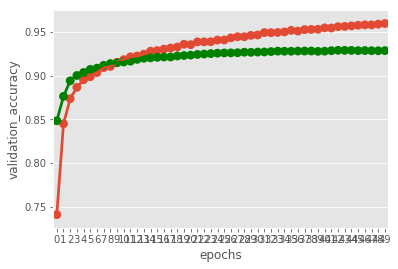

In [35]:
df_result = pd.DataFrame({'epochs':history.epoch, 'accuracy': history.history['acc'], 'validation_accuracy': history.history['val_acc']})
g = sns.pointplot(x="epochs", y="accuracy", data=df_result, fit_reg=False)
g = sns.pointplot(x="epochs", y="validation_accuracy", data=df_result, fit_reg=False, color='green')

In [36]:
test = pd.read_csv("/kaggle/input/usinlppracticum/imdb_test.csv")

In [37]:
test.review = pd.DataFrame(test.review.apply(round1))
test

,id,review
0,1,not only is this movie a great film for basic ...
1,2,waitress honey heres them eggs you ordered hon...
2,3,many mystery stories follow the standard whodu...
3,4,a space ship cruising through the galaxy encou...
4,5,my favorite film this year great characters an...
...,...,...
9995,9996,the premise may seem goofy but since murphys c...
9996,9997,my wife and i watched this abortion from its b...
9997,9998,being a huge street fighter fan and thoroughly...
9998,9999,ok first of all let me say that im still amaze...


In [38]:
test.head()

,id,review
0,1,not only is this movie a great film for basic ...
1,2,waitress honey heres them eggs you ordered hon...
2,3,many mystery stories follow the standard whodu...
3,4,a space ship cruising through the galaxy encou...
4,5,my favorite film this year great characters an...


In [39]:
df_bigram_test = vectorizer.transform(test['review'])

In [40]:
df_bigram_test

<10000x544369 sparse matrix of type '<class 'numpy.float64'>'
	with 1476035 stored elements in Compressed Sparse Row format>

In [41]:
import h5py

In [42]:
with h5py.File('numpy.hdf5', 'w') as f:
    dset = f.create_dataset("default", data=transformed_texts)

In [44]:
del X_train, X_test, y_train, y_test

In [45]:
del df_result

In [46]:
del df_bigram

In [47]:
transformed_texts_test = selector.transform(df_bigram_test).astype('float32').toarray()

In [48]:
model.load_weights(filepath)
predicted = model.predict(transformed_texts_test)

In [49]:
predicted

array([[0.01919438, 0.9852777 ],
       [0.8742679 , 0.10957744],
       [0.08063301, 0.9307528 ],
       ...,
       [0.80757964, 0.17445205],
       [0.97962487, 0.0152646 ],
       [0.98923206, 0.00768619]], dtype=float32)

In [50]:
predicted_best = np.argmax(predicted, axis=1)

In [51]:
predicted_best

array([1, 0, 1, ..., 0, 0, 0])

In [52]:
sam = pd.read_csv("/kaggle/input/usinlppracticum/sample_submission.csv")

In [53]:
for index,data in enumerate(predicted_best):
    if data == 0:
        sam["sentiment"].iloc[index] = "negative"
    else:
        sam["sentiment"].iloc[index] = "positive"

/opt/conda/lib/python3.6/site-packages/pandas/core/indexing.py:205: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_with_indexer(indexer, value)


In [54]:
sam.head()

,id,sentiment
0,1,positive
1,2,negative
2,3,positive
3,4,negative
4,5,positive


In [55]:
sam.to_csv('mysubmission.csv',index=False)